In [105]:
here::i_am("atac/archR/dimensionality_reduction/cells/archR_dimensionality_reduction.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(uwot))

######################
## Define arguments ##
######################

# p <- ArgumentParser(description='')
# p$add_argument('--metadata',        type="character",                               help='Cell metadata file')
# p$add_argument('--matrix',          type="character",  default="PeakMatrix",   help='Matrix to use')
# #p$add_argument('--samples',         type="character",                nargs='+',     help='Samples')
# #p$add_argument('--stages',       type="character",  default="all",  nargs='+',  help='Stages to plot')
# p$add_argument('--remove_ExE_cells',type="character",  default="False",  help='Remove ExE cells? ("True"/"False")')
# p$add_argument('--nfeatures',       type="integer",    default=1000,               help='Number of features')
# p$add_argument('--ndims',           type="integer",    default=30,                  help='Number of LSI dimensions')
# p$add_argument('--batch_variable',  type="character",                               help='Metadata column to apply batch correction on')
# p$add_argument('--batch_method',    type="character",  default="MNN",               help='Batch correctin method ("Harmony" or "MNN")')
# p$add_argument('--n_neighbors',     type="integer",    default=30,   nargs='+',     help='(UMAP) Number of neighbours')
# p$add_argument('--min_dist',        type="double",     default=0.3,  nargs='+',     help='(UMAP) Minimum distance')
# p$add_argument('--colour_by',       type="character",  nargs='+',  help='Metadata columns to colour the UMAP by')
# p$add_argument('--seed',            type="integer",    default=42,                  help='Random seed')
# p$add_argument('--outdir',          type="character",                               help='Output directory')

# args <- p$parse_args(commandArgs(TRUE))

ERROR: Error: Could not find associated project in working directory or any parent directory.
- Path in project: atac/archR/dimensionality_reduction/cells/archR_dimensionality_reduction.R
- Current working directory: /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR
Please open the project associated with this file and try again.


In [44]:

## START TEST ##
args <- list()
args$metadata <- file.path(io$basedir, "results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$nfeatures <- 5000
args$matrix <- "PeakMatrix"
args$ndims <- 15
args$seed <- 42
args$n_neighbors <- 25

args$batch_variable = 'sample'
args$batch_method = 'MNN'

args$min_dist <- 0.3
args$remove_ExE_cells = FALSE
args$colour_by <- c("sample","celltype")
args$vars_to_regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- "/bi/group/reik/ricard/data/gastrulation_multiome_10x/results/atac/archR/dimensionality_reduction"
## END TEST ##

In [34]:


if (args$remove_ExE_cells=="TRUE") {
  args$remove_ExE_cells <- TRUE
} else if (args$remove_ExE_cells=="FALSE") {
  args$remove_ExE_cells <- FALSE 
} else {
  stop('remove_ExE_cells should be "True" or "False"')
}

In [35]:

#####################
## Define settings ##
#####################

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

#if (args$stages[1]=="all") {
#  args$stages <- opts$stages
#} else {
#  stopifnot(args$stages%in%opts$stages)
#}



In [38]:

##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  # .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%args$samples] %>%
  # .[nFrags_atac>=3500 & TSSEnrichment_atac>=9,pass_atacQC:=TRUE] %>% .[stage=="E8.7",stage:="E8.75"] %>%    # temporary
  .[pass_atacQC==TRUE & doublet_call==FALSE & sample%in%opts$samples] %>%
  .[,log_nFrags_atac:=log10(nFrags_atac)]
  
stopifnot(args$colour_by %in% colnames(sample_metadata))

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

table(sample_metadata$stage)
table(sample_metadata$celltype)


< table of extent 0 >


     Anterior_Primitive_Streak                  Def._endoderm 
                            62                              4 
                      Epiblast                   ExE_endoderm 
                             3                              1 
                  ExE_mesoderm   Forebrain_Midbrain_Hindbrain 
                           216                              6 
                           Gut Haematoendothelial_progenitors 
                            20                            128 
         Intermediate_mesoderm                     Mesenchyme 
                           217                              5 
                Mixed_mesoderm               Nascent_mesoderm 
                           664                           2475 
             Paraxial_mesoderm                            PGC 
                             6                             86 
           Pharyngeal_mesoderm               Primitive_Streak 
                            27                        

In [42]:

########################
## Load ArchR project ##
########################

source(here::here("atac/archR/load_archR_project.R"))

# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]
# ArchRProject.filt@sampleColData <- ArchRProject.filt@sampleColData[args$samples,,drop=F]

###################
## Sanity checks ##
###################

stopifnot(args$matrix %in% getAvailableMatrices(ArchRProject))

if (args$batch_variable!='None') {
  stopifnot(args$batch_variable%in%colnames(sample_metadata))
  if (length(unique(sample_metadata[[args$batch_variable]]))==1) {
    message(sprintf("There is a single level for %s, no batch correction applied",args$batch_variable))
    args$batch_variable <- NULL
  } else {
    library(batchelor)
  }
}

if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
}

###########################
## Update ArchR metadata ##
###########################

sample_metadata.to.archr <- sample_metadata %>% 
  .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
for (i in args$colour_by) {
  ArchRProject.filt <- addCellColData(
    ArchRProject.filt,
    data = sample_metadata.to.archr[[i]],
    name = i,
    cells = rownames(sample_metadata.to.archr),
    force = TRUE
  )
  print(table(getCellColData(ArchRProject.filt,i)[[1]]))
}


#######################
## Feature selection ##
#######################

# if (args$matrix=="PeakMatrix_filt") {
  
#   # Load peak variability estimates
#   peak.variability.dt <- fread(io$archR.peak.variability)
  
#   # Define highly variable peaks
#   peaks <- peak.variability.dt %>% 
#     .[,peak:=sub("_",":",peak)] %>% .[,peak:=sub("_","-",peak)] %>%
#     setorder(-variance_pseudobulk) %>% 
#     head(n=args$nfeatures) %>% 
#     .$peak
  
#   # Subset peaks in the ArchR object
#   names(ArchRProject.filt@peakSet) <- sprintf("%s:%s-%s",seqnames(ArchRProject.filt@peakSet), start(ArchRProject.filt@peakSet), end(ArchRProject.filt@peakSet))
#   ArchRProject.filt@peakSet[peaks,] <- ArchRProject.filt@peakSet[peaks,]
  
#   ArchRProject.filt <- addFeatureMatrix(
#     input = ArchRProject.filt,
#     features = ArchRProject.filt@peakSet,
#     matrixName = "PeakMatrix_filt",
#     binarize = TRUE
#   )
  
# }


Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__


rv_eo_deg_day3_5_control    rv_eo_deg_day3_5_dtag 
                    2545                     1942 


Overriding previous entry for celltype




     Anterior_Primitive_Streak                  Def._endoderm 
                            62                              4 
                      Epiblast                   ExE_endoderm 
                             3                              1 
                  ExE_mesoderm   Forebrain_Midbrain_Hindbrain 
                           216                              6 
                           Gut Haematoendothelial_progenitors 
                            20                            128 
         Intermediate_mesoderm                     Mesenchyme 
                           217                              5 
                Mixed_mesoderm               Nascent_mesoderm 
                           664                           2475 
             Paraxial_mesoderm                            PGC 
                             6                             86 
           Pharyngeal_mesoderm               Primitive_Streak 
                            27                        

In [45]:

###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
   clusterParams = list(
    resolution = opts$lsi.cluster.resolution, 
    sampleCells = 10000, 
    maxClusters=NULL,
    n.start = 10
   ), 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  dimsToUse = 1:args$ndims,
  force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-10b6726c3e594-Date-2022-06-09_Time-12-46-12.log
If there is an issue, please report to github with logFile!

2022-06-09 12:46:15 : Computing Total Across All Features, 0.002 mins elapsed.

2022-06-09 12:46:15 : Computing Top Features, 0.016 mins elapsed.

###########
2022-06-09 12:46:17 : Running LSI (1 of 2) on Top Features, 0.037 mins elapsed.
###########

2022-06-09 12:46:17 : Creating Partial Matrix, 0.038 mins elapsed.

2022-06-09 12:46:41 : Computing LSI, 0.438 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2022-06-09 12:46:55 : Identifying Clusters, 0.68 mins elapsed.

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”
2022-06-09 12:47:07 : Identified 13 Clusters, 0.875 mins elapsed.

2022-06-09 12:47:07 : Creating Cluster Matrix on the total Group Features, 0.876 mins elapsed.

2022-06-09 12:47:55 : Computing Variable Features, 1.67 mins elapsed.

###########
2022-06-

In [46]:
 outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/lsi_nfeatures%d_dims%d.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims)

In [99]:
lsi.mtx <- getReducedDims(ArchRProject.filt, "IterativeLSI")
lsi.mtx <- lsi.mtx[,which(abs(cor(lsi.mtx,sample_metadata$nFrags_atac))<=0.75)]

In [100]:
sample_metadata$stage = sample_metadata$day

In [96]:
    # Define stage and sample order
    stopifnot(sample_metadata$cell==rownames(lsi.mtx))
    timepoints <- sample_metadata$stage
    timepoint_order <- opts$stages[opts$stages%in%timepoints]
    samples <- sample_metadata$sample
    sample_order <- opts$samples[opts$samples%in%samples]
    
    lsi_list    <- lapply(unique(timepoints), function(i){
      sub_pc   <- lsi.mtx[timepoints == i, , drop = FALSE]
      sub_samp <- samples[timepoints == i]
      list     <- lapply(unique(sub_samp), function(j){ sub_pc[sub_samp == j, , drop = FALSE]})
      names(list) <- unique(sub_samp)
      return(list)
    })
    names(lsi_list) <- unique(timepoints)
    
    #arrange to match timepoint order
    lsi_list <- lsi_list[order(match(names(lsi_list), timepoint_order))]
    lsi_list <- lapply(lsi_list, function(x){ x[order(match(names(x), sample_order))]})
    
    #perform corrections within stages
    correct_list <- lapply(lsi_list, function(x){
      if(length(x) > 1){
        return(do.call(reducedMNN, x)$corrected)
      } else {
        return(x[[1]])
      }
    })
    
    # perform correction over stages
      if(length(correct_list) > 1){
        lsi.mtx <- reducedMNN(correct_list, merge.order=1:length(correct_list))$corrected 
      } else {
        lsi.mtx <- correct_list[[1]]
      }

    rm(correct_list,lsi_list)
    

In [101]:
######################
## Batch correction ##
######################

if (length(args$batch_variable)>0) {
  print(sprintf("Applying %s batch correction for variable: %s", args$batch_method, args$batch_variable))
  # Harmony
  if (args$batch_method=="Harmony") {
    stop("Not implemented")
    # (...)
    # library(harmony)
    # harmonyParams <- list(...)
    # harmonyParams$data_mat <- getReducedDims(
    #   ArchRProj = ArchRProj, 
    #   reducedDims = reducedDims, 
    #   dimsToUse = dimsToUse, 
    #   scaleDims = scaleDims, 
    #   corCutOff = corCutOff
    # )
    # harmonyParams$verbose <- verbose
    # harmonyParams$meta_data <- data.frame(getCellColData(
    #   ArchRProj = ArchRProj, 
    #   select = groupBy)[rownames(harmonyParams$data_mat), , drop = FALSE])
    # harmonyParams$do_pca <- FALSE
    # harmonyParams$vars_use <- groupBy
    # harmonyParams$plot_convergence <- FALSE
    
    # lsi.dt <- getReducedDims(ArchRProject, "IterativeLSI_Harmony") %>% round(3) %>% 
    #   as.data.table(keep.rownames = T) %>% setnames("rn","cell")

  } else if (args$batch_method=="MNN") {
      
    stopifnot(args$batch_variable=="sample")
    
    # Define stage and sample order
    stopifnot(sample_metadata$cell==rownames(lsi.mtx))
    timepoints <- sample_metadata$stage
    timepoint_order <- opts$stages[opts$stages%in%timepoints]
    samples <- sample_metadata$sample
    sample_order <- opts$samples[opts$samples%in%samples]
    
    lsi_list    <- lapply(unique(timepoints), function(i){
      sub_pc   <- lsi.mtx[timepoints == i, , drop = FALSE]
      sub_samp <- samples[timepoints == i]
      list     <- lapply(unique(sub_samp), function(j){ sub_pc[sub_samp == j, , drop = FALSE]})
      names(list) <- unique(sub_samp)
      return(list)
    })
    names(lsi_list) <- unique(timepoints)
    
    #arrange to match timepoint order
    lsi_list <- lsi_list[order(match(names(lsi_list), timepoint_order))]
    lsi_list <- lapply(lsi_list, function(x){ x[order(match(names(x), sample_order))]})
    
    #perform corrections within stages
    correct_list <- lapply(lsi_list, function(x){
      if(length(x) > 1){
        return(do.call(reducedMNN, x)$corrected)
      } else {
        return(x[[1]])
      }
    })
    
    # perform correction over stages
      if(length(correct_list) > 1){
        lsi.mtx <- reducedMNN(correct_list, merge.order=1:length(correct_list))$corrected 
      } else {
        lsi.mtx <- correct_list[[1]]
      }

    rm(correct_list,lsi_list)
  } else {
    stop("Batch correction method not recognised")
  }
}


[1] "Applying MNN batch correction for variable: sample"


In [103]:
# Save LSI coordinates
 outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/lsi_nfeatures%d_dims%d.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims)

lsi.dt <- lsi.mtx %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")
fwrite(lsi.dt, outfile)

ERROR: Error in fwrite(lsi.dt, outfile): No such file or directory: '/bi/group/reik/ricard/data/gastrulation_multiome_10x/results/atac/archR/dimensionality_reduction/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_sample/lsi_nfeatures5000_dims15.txt.gz'. Unable to create new file for writing (it does not exist already). Do you have permission to write here, is there space on the disk and does the path exist?


Loading required package: viridisLite



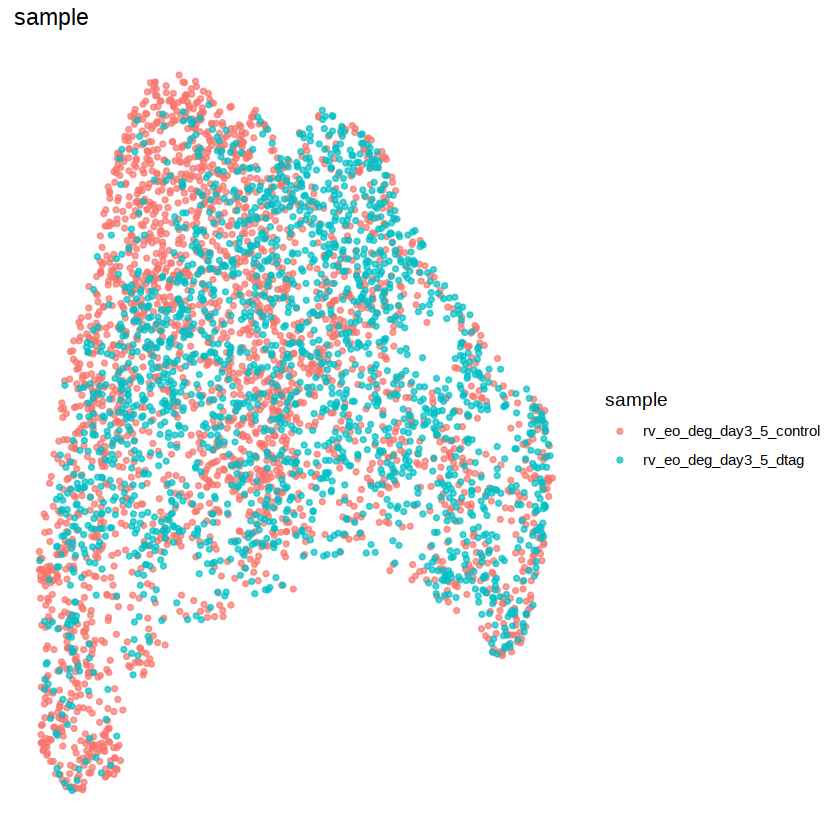

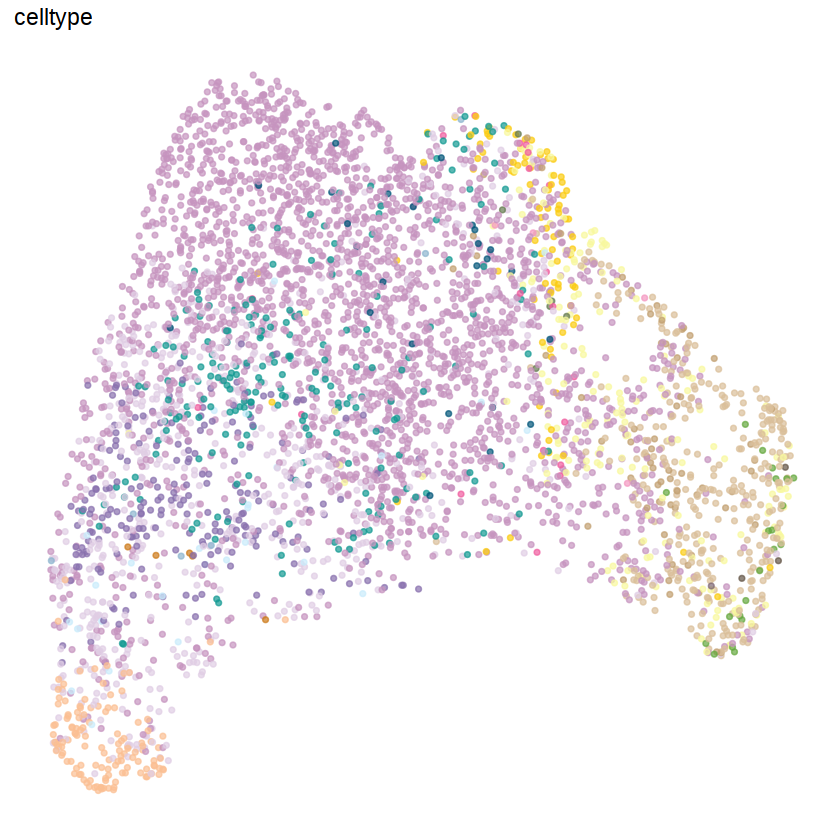

In [107]:
##########
## UMAP ##
##########

# i <- args$n_neighbors[1]
# j <- args$min_dist[1]
for (i in args$n_neighbors) {
  for (j in args$min_dist) {

    # Run UMAP
    set.seed(args$seed)
    umap_embedding.mtx <- umap(lsi.mtx, n_neighbors=i, min_dist=j, metric="cosine", fast_sgd = TRUE) %>% round(2)
    rownames(umap_embedding.mtx) <- rownames(lsi.mtx)
    
    # Fetch UMAP coordinates
    umap.dt <- umap_embedding.mtx %>%
      as.data.table(keep.rownames = T) %>%
      setnames(c("cell","umap1","umap2"))
    
    # Save UMAP coordinates
    outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%g.txt.gz", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j)
}


    # Plot
    to.plot <- umap.dt %>%
      merge(sample_metadata,by="cell")
    
    for (k in args$colour_by) {
          library(viridis)
          
          # log10 large numeric values
          if (is.numeric(to.plot[[k]])) {
            if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
              to.plot[[k]] <- log10(to.plot[[k]]+1)
              to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
            }
          }

          p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", col=k)) +
            geom_point(size=1, alpha = 0.7) +
            # ggrastr::geom_point_rast(size=1.5, shape=21, stroke=0.05) +  # DOES NOT WORK IN THE CLUSTER
            theme_classic() + ggtitle(k) +
            ggplot_theme_NoAxes()

          # Define colormap
          if (is.numeric(to.plot[[k]])) {
            p <- p + scale_color_viridis() 
          }

          if (grepl("celltype",k)) {
            p <- p + scale_color_manual(values=opts$celltype.colors) +
              theme(
                legend.position="none",
                legend.title=element_blank()
              )
          }

          if (grepl("day",k)) {
            p <- p + scale_color_viridis(discrete=TRUE) + 
              theme(
                legend.title=element_blank()
              )

          }
      # Save UMAP plot
      # outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j, k)
          outfile <- sprintf("%s/%s/remove_ExE_cells_%s/batch_correction_%s/umap_nfeatures%d_dims%d_nneighbour%d_mindist%g_%s.pdf", 
      args$outdir, 
      args$matrix, 
      args$remove_ExE_cells, 
      paste(args$batch_variable,collapse="-"), 
      args$nfeatures, 
      args$ndims,
      i,
      j,
      k)
      print(p)

    }
    
  }